In [ ]:
# hypothesis testing
# https://towardsdatascience.com/p-value-method-for-hypothesis-testing-c967c0f78d74

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm # ttest -> test statistic, pvalue, dof
from scipy.stats import t,ttest_ind,chisquare,chi2 # plotting, ttest

In [12]:
connect_df = pd.read_csv('~/Downloads/CrazyEgg/connect/Homepage-Connect.csv')
help_df = pd.read_csv('~/Downloads/CrazyEgg/help/Homepage-Help.csv')
learn_df = pd.read_csv('~/Downloads/CrazyEgg/learn/Homepage-Learn.csv')
services_df = pd.read_csv('~/Downloads/CrazyEgg/services/Homepage-Services.csv')
interact_df = pd.read_csv('~/Downloads/CrazyEgg/interact/Homepage-Interact.csv')



In [9]:
connect_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Element ID            58 non-null     int64 
 1   Tag name              58 non-null     object
 2   Name                  58 non-null     object
 3   No. clicks            58 non-null     int64 
 4   Visible?              58 non-null     bool  
 5   Snapshot information  2 non-null      object
dtypes: bool(1), int64(2), object(3)
memory usage: 2.4+ KB


In [8]:
help_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Element ID            57 non-null     int64 
 1   Tag name              57 non-null     object
 2   Name                  57 non-null     object
 3   No. clicks            57 non-null     int64 
 4   Visible?              57 non-null     bool  
 5   Snapshot information  2 non-null      object
dtypes: bool(1), int64(2), object(3)
memory usage: 2.4+ KB


In [7]:
learn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Element ID            62 non-null     int64 
 1   Tag name              62 non-null     object
 2   Name                  62 non-null     object
 3   No. clicks            62 non-null     int64 
 4   Visible?              62 non-null     bool  
 5   Snapshot information  2 non-null      object
dtypes: bool(1), int64(2), object(3)
memory usage: 2.6+ KB


In [6]:
services_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Element ID            53 non-null     int64 
 1   Tag name              53 non-null     object
 2   Name                  53 non-null     object
 3   No. clicks            53 non-null     int64 
 4   Visible?              53 non-null     bool  
 5   Snapshot information  2 non-null      object
dtypes: bool(1), int64(2), object(3)
memory usage: 2.2+ KB


In [13]:
# clicks
print(connect_df['No. clicks'].mean())
print(help_df['No. clicks'].mean())
print(learn_df['No. clicks'].mean())
print(services_df['No. clicks'].mean())
print(interact_df['No. clicks'].mean())

# interact has the most CTR

27.362068965517242
30.12280701754386
26.64516129032258
25.433962264150942
53.82608695652174


In [ ]:
alpha = .025 # one-tail test

In [23]:
con_se = connect_df['No. clicks']
hel_se = help_df['No. clicks']
le_se = learn_df['No. clicks']
ser_se = services_df['No. clicks']
int_se = interact_df['No. clicks']


In [31]:
print('tscore, pval, dof')
print(sm.stats.ttest_ind(con_se,hel_se))
print(sm.stats.ttest_ind(con_se,le_se))
print(sm.stats.ttest_ind(con_se,ser_se))
print(sm.stats.ttest_ind(con_se,int_se))

# comparing pvalue
# con vs all
# pval > alpha -> not reject H0
# pval < alpha ->  reject H0

tscore, pval, dof
(-0.16409092293682248, 0.8699527129702564, 113.0)
(0.046493383555106176, 0.9629956019734648, 118.0)
(0.13118419444524448, 0.8958714224255175, 109.0)
(-0.9740469572622015, 0.33191441425351087, 125.0)


In [28]:
# help vs all
print(sm.stats.ttest_ind(hel_se,con_se))
print(sm.stats.ttest_ind(hel_se,int_se))
print(sm.stats.ttest_ind(hel_se,ser_se))
print(sm.stats.ttest_ind(hel_se,le_se))



(0.16409092293682248, 0.8699527129702564, 113.0)
(-0.8446068413681795, 0.3999570032479679, 124.0)
(0.2867680701994167, 0.774839340838325, 108.0)
(0.20690297241059266, 0.8364452901947725, 117.0)


In [29]:
# services vs all
print(sm.stats.ttest_ind(ser_se,con_se))
print(sm.stats.ttest_ind(ser_se,int_se))
print(sm.stats.ttest_ind(ser_se,hel_se))
print(sm.stats.ttest_ind(ser_se,le_se))



(-0.13118419444524448, 0.8958714224255175, 109.0)
(-1.0210986532335857, 0.30926185388653743, 120.0)
(-0.2867680701994167, 0.774839340838325, 108.0)
(-0.08143966744286986, 0.9352363760090467, 113.0)


In [30]:
# learn vs all
print(sm.stats.ttest_ind(le_se,con_se))
print(sm.stats.ttest_ind(le_se,int_se))
print(sm.stats.ttest_ind(le_se,hel_se))
print(sm.stats.ttest_ind(le_se,ser_se))

(-0.046493383555106176, 0.9629956019734648, 118.0)
(-1.0237360143562562, 0.30787591805945347, 129.0)
(-0.20690297241059266, 0.8364452901947725, 117.0)
(0.08143966744286986, 0.9352363760090467, 113.0)


In [ ]:
# pvalue sorted: learn, services, connect, help, interact

In [39]:
# if pvalue > alpha:
#   print("The p-value is larger than alpha.")
# else:
#   print("The p-value is smaller than alpha.")

In [ ]:
# print('Since the p-value is smaller than the alpha, we reject the Null Hypothesis.
# 

In [66]:
# Null Hypothesis: all versions have the same CTR.
# Alternative Hypothesis: there is a difference in the CTR for the different versions.

In [68]:
from scipy.stats import norm


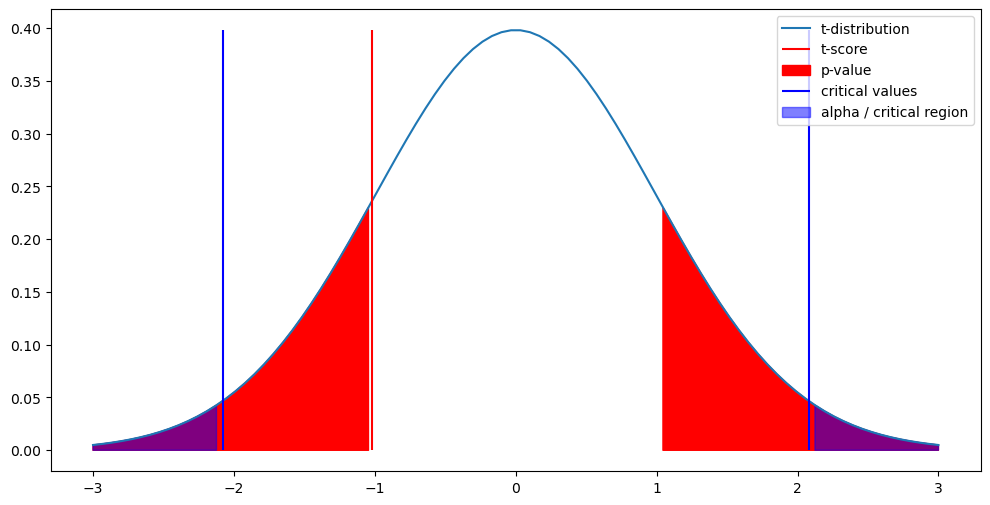

In [92]:
# learn vs integrate CTR
# dof = 129 # learn vs integrate
dof = 120 # ser vs int
# ztable lookup
# cv = 1.98
cv = 2.02
# t_score = -1.0237360143562562 # learn vs integrate
t_score = -1.0210986532335857 # ser vs int
xt = np.linspace(-3,3,90)



plt.figure(figsize=(12,6))
# Plot a t-distribution with the degrees of freedom from our sample.
plt.plot(xt, t.pdf(xt,dof), label="t-distribution")
# Add a vertical line for the t-score.
plt.vlines(t_score, ymin=0, ymax=max(t.pdf(xt,dof)), color="red", label="t-score")
# Shade the region in the tails that is more extreme than the +/-t-score (= p-value).
plt.fill_between(xt, t.pdf(xt,dof), where=(-abs(t_score)>xt)|(xt>abs(t_score)), color= "r", label="p-value")
# Add vertical lines for the critical values.
plt.vlines(-2.08, ymin=0, ymax=max(t.pdf(xt,dof)), color="blue", label="critical values")
plt.vlines(2.08, ymin=0, ymax=max(t.pdf(xt,dof)), color="blue")
# Shade the area under the curve for values more extreme than +/-2.08 (= alpha).
plt.fill_between(xt, t.pdf(xt,dof), where=(-2.08>xt)|(xt>2.08), color= "b", alpha=0.5, label="alpha / critical region")
plt.legend()
plt.show()




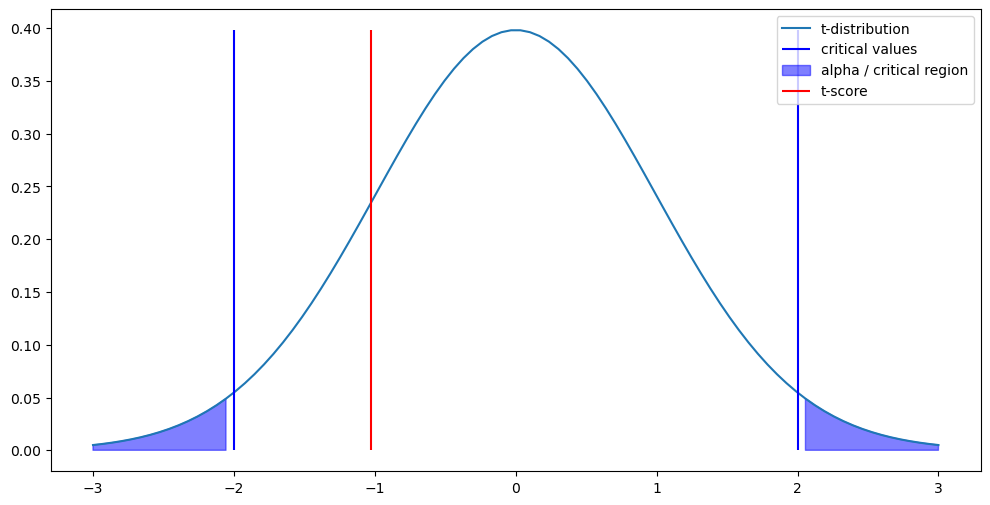

In [80]:
#@title t-distribution and t-score
plt.figure(figsize=(12,6))
# Plot a t-distribution with the degrees of freedom from our sample.
plt.plot(xt, t.pdf(xt,dof), label="t-distribution")
plt.vlines(-2.0, ymin=0, ymax=max(t.pdf(xt,dof)), color="blue", label="critical values")
plt.vlines(2.0, ymin=0, ymax=max(t.pdf(xt,dof)), color="blue")
# Shade the area under the curve for values more extreme than +/-2.08 (= alpha).
plt.fill_between(xt, t.pdf(xt,dof), where=(-2.0>xt)|(xt>2.0), color= "b", alpha=0.5, label="alpha / critical region")


# Add a vertical line for the t-score.
plt.vlines(t_score, ymin=0, ymax=max(t.pdf(xt,dof)), color="red", label="t-score")
plt.legend()
plt.show()

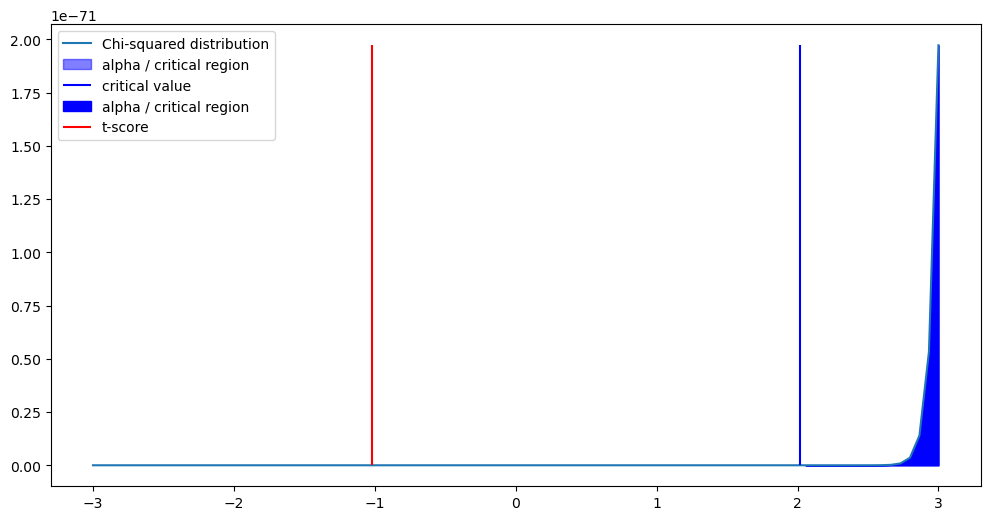

In [115]:
#@title t-distribution and t-score
plt.figure(figsize=(12,6))
# Plot a t-distribution with the degrees of freedom from our sample.
plt.plot(xt, chi2.pdf(xt,dof), label="Chi-squared distribution")
# plt.vlines(-2.0, ymin=0, ymax=max(chi2.pdf(xt,dof)), color="blue", label="critical values")
# plt.vlines(2.0, ymin=0, ymax=max(chi2.pdf(xt,dof)), color="blue")
# Shade the area under the curve for values more extreme than +/-2.08 (= alpha).
plt.fill_between(xt, chi2.pdf(xt,dof), where=(xt>cv), color= "b", alpha=0.5, label="alpha / critical region")

# Add vertical line for the critical value.
plt.vlines(cv, ymin=0, ymax=max(chi2.pdf(xt,dof)), color="blue", label="critical value")

# Shade the area under the curve for values more extreme than 4.6 (= alpha).
plt.fill_between(xt, chi2.pdf(xt,dof), where=(xt>cv), color= "b", label="alpha / critical region")


# Add a vertical line for the t-score.
plt.vlines(t_score, ymin=0, ymax=max(chi2.pdf(xt,dof)), color="red", label="t-score")
plt.legend()
plt.show()

In [ ]:
# let s1.sample s2.sample
# get s1_mean s2_mean
# sm.stats.ttest_ind(s1,s2)

In [103]:
chisquare(le_se)


Power_divergenceResult(statistic=16941.845036319617, pvalue=0.0)

In [104]:
chisquare(int_se)


Power_divergenceResult(statistic=46785.41680129239, pvalue=0.0)

In [91]:
services_df.groupby(['Element ID','Tag name','Name']).count()

,,,No. clicks,Visible?,Snapshot information
Element ID,Tag name,Name,,,
3,img,Montana State University in Bozeman,1,1,0
6,a,Ask A Librarian,1,1,0
8,div,logo-ikd,1,1,0
14,div,Montana State University Historical Photographs,1,1,0
15,p,Montana State University Historical Photographs,1,1,0
18,p,Indian Peoples of the Northern Great Plains,1,1,0
19,div,Meet with a librarian for help with your research topic Chat with a librarian Schedule a meeting Cal,1,1,0
25,a,Schedule a meeting,1,1,0
29,a,slideshow-left,1,1,0
